In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import copy

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, recall_score, precision_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from data_preparation import prepare_water_data
from model import get_model, FocalLoss
from train import train_model, find_best_threshold

c:\Users\nesto\AppData\Local\anaconda3\envs\dl4td\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\nesto\AppData\Local\anaconda3\envs\dl4td\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
warnings.filterwarnings("ignore")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Usando dispositivo: {device}")
print(f" PyTorch version: {torch.__version__}")

 Usando dispositivo: cuda
 PyTorch version: 2.5.1


In [3]:
df = pd.read_csv('../data/raw_drinking_water_potability.csv')
print("Dataset shape:", df.shape)

Dataset shape: (3276, 10)


In [4]:
print("\n=== LIMPIANDO DATOS ===")
# Mostrar valores nulos antes
nulos_antes = df.isnull().sum().sum()
print(f"Valores nulos antes: {nulos_antes}")

# Rellenar con la media
df = df.fillna(df.mean())

# Verificar después
nulos_despues = df.isnull().sum().sum()
print(f"Valores nulos después: {nulos_despues}")

# Estadísticas descriptivas
print(f"\nEstadísticas descriptivas:")
print(df.describe())


=== LIMPIANDO DATOS ===
Valores nulos antes: 1434
Valores nulos después: 0

Estadísticas descriptivas:
                ph     Hardness        Solids  Chloramines      Sulfate  \
count  3276.000000  3276.000000   3276.000000  3276.000000  3276.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.469956    32.879761   8768.570828     1.583085    36.142612   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.277673   176.850538  15666.690300     6.127421   317.094638   
50%       7.080795   196.967627  20927.833605     7.130299   333.775777   
75%       7.870050   216.667456  27332.762125     8.114887   350.385756   
max      14.000000   323.124000  61227.196010    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Potability  
count   3276.000000     3276.000000      3276.000000  3276.000000  3276.000000  
mean     426.205111       14.284970        66.396293     3


=== ANÁLISIS DE BALANCE DE CLASES ===
Potability
0    1998
1    1278
Name: count, dtype: int64

Porcentajes:
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


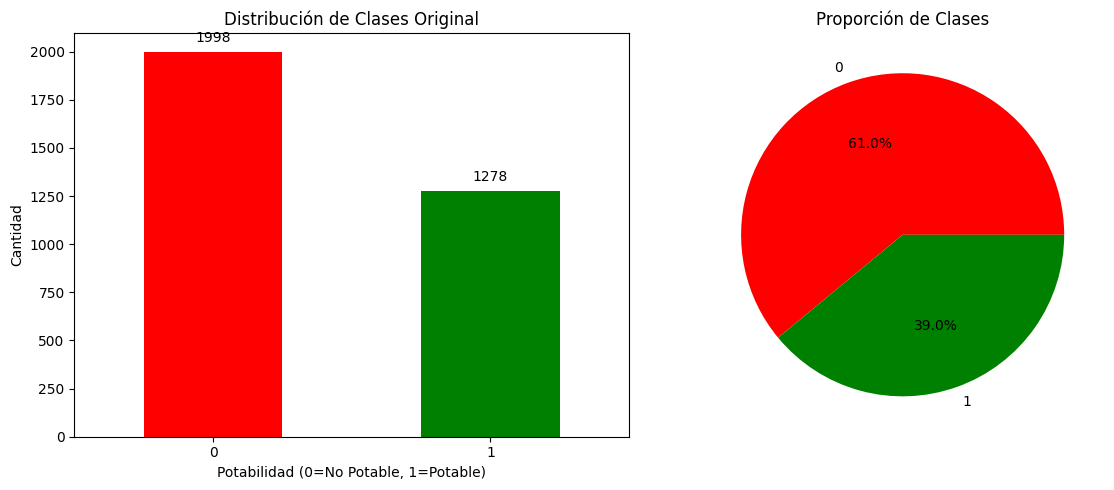

In [5]:
print("\n=== ANÁLISIS DE BALANCE DE CLASES ===")
print(df['Potability'].value_counts())
print(f"\nPorcentajes:")
print(df['Potability'].value_counts(normalize=True) * 100)

# Visualizar balance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Potability'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Distribución de Clases Original')
plt.xlabel('Potabilidad (0=No Potable, 1=Potable)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
for i, v in enumerate(df['Potability'].value_counts().values):
    plt.text(i, v + 50, str(v), ha='center')

plt.subplot(1, 2, 2)
df['Potability'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Proporción de Clases')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [6]:
print("\n=== PREPARANDO DATASETS ===")

# Separar características y etiquetas
X = df.drop('Potability', axis=1).values.astype(np.float32)
y = df['Potability'].values.astype(np.float32)

print(f"Características: {X.shape[1]} variables")
print(f"Muestras totales: {len(X)}")
print(f"Clase 0 (No Potable): {sum(y==0)} muestras")
print(f"Clase 1 (Potable): {sum(y==1)} muestras")

# División train/val manteniendo proporción de clases
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train)} muestras")
print(f"  - No Potable: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  - Potable: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"Validation: {len(X_val)} muestras")
print(f"  - No Potable: {sum(y_val==0)}")
print(f"  - Potable: {sum(y_val==1)}")


=== PREPARANDO DATASETS ===
Características: 9 variables
Muestras totales: 3276
Clase 0 (No Potable): 1998 muestras
Clase 1 (Potable): 1278 muestras

Train: 2620 muestras
  - No Potable: 1598 (61.0%)
  - Potable: 1022 (39.0%)
Validation: 656 muestras
  - No Potable: 400
  - Potable: 256



=== BALANCEO AVANZADO DE CLASES ===
Balance original en entrenamiento:
  No Potable: 1598
  Potable: 1022

1. Aplicando BorderlineSMOTE...
  Balance después: No Potable=1598, Potable=1598

2. Aplicando SMOTETomek (opcional)...
  Balance después: No Potable=1402, Potable=1402


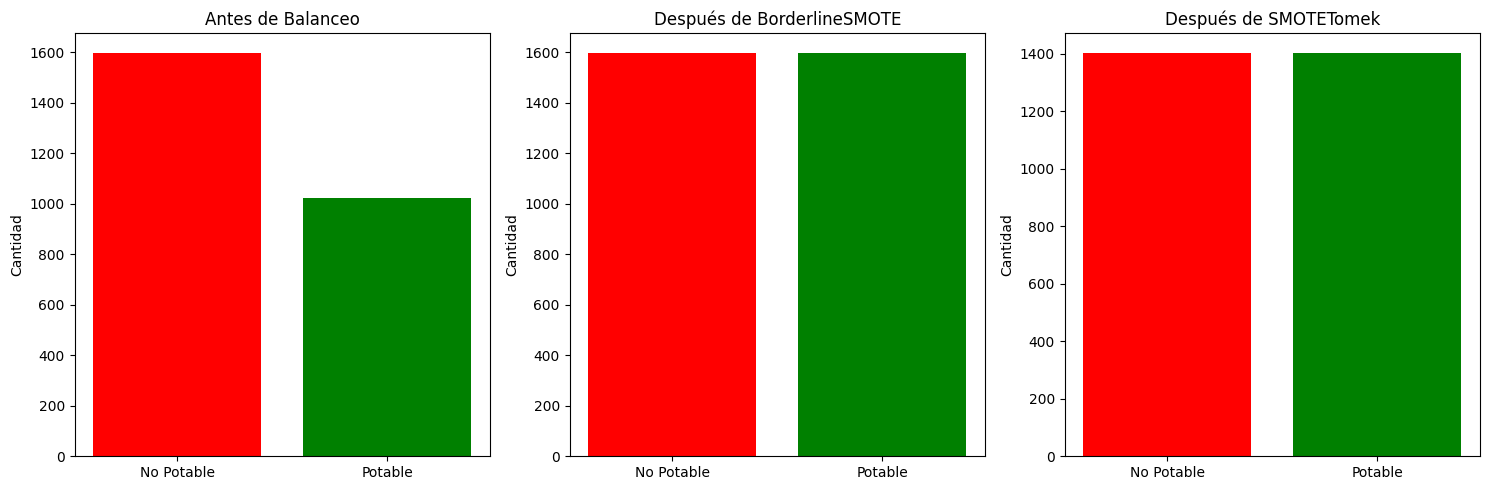

In [7]:
print("\n=== BALANCEO AVANZADO DE CLASES ===")

# Mostrar balance original
print("Balance original en entrenamiento:")
print(f"  No Potable: {sum(y_train==0)}")
print(f"  Potable: {sum(y_train==1)}")

# Opción 1: BorderlineSMOTE (recomendado para mejorar recall)
print("\n1. Aplicando BorderlineSMOTE...")
borderline_smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_bal, y_train_bal = borderline_smote.fit_resample(X_train, y_train)

print(f"  Balance después: No Potable={sum(y_train_bal==0)}, Potable={sum(y_train_bal==1)}")

# Opción 2: SMOTE + Tomek (limpieza de bordes)
print("\n2. Aplicando SMOTETomek (opcional)...")
smote_tomek = SMOTETomek(random_state=42)
X_train_bal2, y_train_bal2 = smote_tomek.fit_resample(X_train, y_train)

print(f"  Balance después: No Potable={sum(y_train_bal2==0)}, Potable={sum(y_train_bal2==1)}")

# Usar BorderlineSMOTE por defecto
X_train_final, y_train_final = X_train_bal, y_train_bal

# Visualizar comparación
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(['No Potable', 'Potable'], [sum(y_train==0), sum(y_train==1)], color=['red', 'green'])
plt.title('Antes de Balanceo')
plt.ylabel('Cantidad')

plt.subplot(1, 3, 2)
plt.bar(['No Potable', 'Potable'], [sum(y_train_bal==0), sum(y_train_bal==1)], color=['red', 'green'])
plt.title('Después de BorderlineSMOTE')
plt.ylabel('Cantidad')

plt.subplot(1, 3, 3)
plt.bar(['No Potable', 'Potable'], [sum(y_train_bal2==0), sum(y_train_bal2==1)], color=['red', 'green'])
plt.title('Después de SMOTETomek')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()


=== TRANSFORMANDO A IMÁGENES ===
=== TRANSFORMANDO DATOS A IMÁGENES ===
Transformando 3852 muestras a imágenes 64x64...
  Progreso: 100/3852 muestras (0.2s)
  Progreso: 200/3852 muestras (0.4s)
  Progreso: 300/3852 muestras (0.5s)
  Progreso: 400/3852 muestras (0.6s)
  Progreso: 500/3852 muestras (0.8s)
  Progreso: 600/3852 muestras (1.0s)
  Progreso: 700/3852 muestras (1.1s)
  Progreso: 800/3852 muestras (1.3s)
  Progreso: 900/3852 muestras (1.4s)
  Progreso: 1000/3852 muestras (1.5s)
  Progreso: 1100/3852 muestras (1.5s)
  Progreso: 1200/3852 muestras (1.6s)
  Progreso: 1300/3852 muestras (1.8s)
  Progreso: 1400/3852 muestras (2.0s)
  Progreso: 1500/3852 muestras (2.2s)
  Progreso: 1600/3852 muestras (2.4s)
  Progreso: 1700/3852 muestras (2.5s)
  Progreso: 1800/3852 muestras (2.7s)
  Progreso: 1900/3852 muestras (2.9s)
  Progreso: 2000/3852 muestras (3.0s)
  Progreso: 2100/3852 muestras (3.1s)
  Progreso: 2200/3852 muestras (3.2s)
  Progreso: 2300/3852 muestras (3.4s)
  Progreso: 24

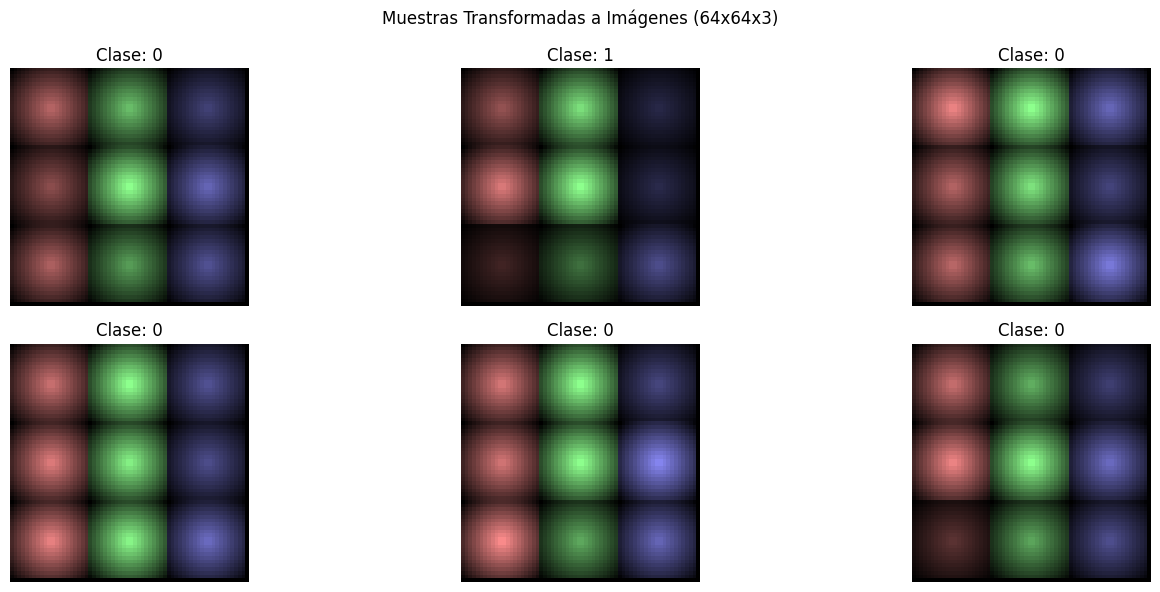

In [8]:
print("\n=== TRANSFORMANDO A IMÁGENES ===")
start_time = time.time()

# Transformar datos balanceados a imágenes
train_images, val_images = prepare_water_data(X_train_final, X_val, force_recompute=True)

transform_time = time.time() - start_time
print(f"\n Transformación completada en {transform_time:.2f} segundos")
print(f"Train images shape: {train_images.shape}")
print(f"Val images shape: {val_images.shape}")
print(f"Rango de valores: [{train_images.min():.3f}, {train_images.max():.3f}]")

# Visualizar algunas muestras transformadas
plt.figure(figsize=(15, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    img_to_show = np.transpose(train_images[i], (1, 2, 0))
    # Normalizar para visualización
    img_to_show = (img_to_show - img_to_show.min()) / (img_to_show.max() - img_to_show.min() + 1e-8)
    plt.imshow(img_to_show)
    plt.title(f'Clase: {int(y_train_final[i])}')
    plt.axis('off')
plt.suptitle('Muestras Transformadas a Imágenes (64x64x3)')
plt.tight_layout()
plt.show()

In [9]:
print("\n=== PREPARANDO DATALOADERS ===")

# Convertir a tensores
X_train_tensor = torch.from_numpy(train_images).float()
y_train_tensor = torch.from_numpy(y_train_final).float().view(-1, 1)
X_val_tensor = torch.from_numpy(val_images).float()
y_val_tensor = torch.from_numpy(y_val).float().view(-1, 1)

# Crear datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Crear dataloaders
batch_size = 32
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
}
dataset_sizes = {
    'train': len(X_train_tensor),
    'val': len(X_val_tensor)
}

print(f"Batch size: {batch_size}")
print(f"Batches por época (train): {len(dataloaders['train'])}")
print(f"Batches por época (val): {len(dataloaders['val'])}")


=== PREPARANDO DATALOADERS ===
Batch size: 32
Batches por época (train): 100
Batches por época (val): 21


In [10]:
print("\n=== CONFIGURANDO MODELO MEJORADO ===")

# Crear modelo mejorado
model = get_model(
    model_type='improved',
    num_classes=1,
    dropout_rate=0.4,
    use_pretrained=True
).to(device)

print("Modelo SuperTMLMejorado creado")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Calcular pesos para clases desbalanceadas
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
print(f"\nPesos de clases: No Potable={class_weights[0]:.2f}, Potable={class_weights[1]:.2f}")

# Opción 1: BCEWithLogitsLoss con peso (tradicional)
pos_weight = torch.tensor([class_weights[1] / class_weights[0] * 1.5]).to(device)  # Escalar 1.5x
criterion_bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Opción 2: Focal Loss (recomendado para recall)
criterion_focal = FocalLoss(alpha=0.25, gamma=2.0)

# Usar Focal Loss por defecto
criterion = criterion_focal
print(f"\nUsando: Focal Loss (alpha=0.25, gamma=2.0)")

# Optimizador con diferentes learning rates
optimizer = optim.Adam([
    {'params': model.backbone.layer4.parameters(), 'lr': 5e-5},
    {'params': model.backbone.layer3.parameters(), 'lr': 5e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], lr=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)

print("\nConfiguración completada:")
print(f"  - Loss: Focal Loss")
print(f"  - Optimizer: Adam (LRs diferenciados)")
print(f"  - Scheduler: ReduceLROnPlateau")


=== CONFIGURANDO MODELO MEJORADO ===
Modelo SuperTMLMejorado creado
Parámetros totales: 11,597,633
Parámetros entrenables: 10,922,241

Pesos de clases: No Potable=0.82, Potable=1.28

Usando: Focal Loss (alpha=0.25, gamma=2.0)

Configuración completada:
  - Loss: Focal Loss
  - Optimizer: Adam (LRs diferenciados)
  - Scheduler: ReduceLROnPlateau


In [11]:
best_model, history = train_model(
    model,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer,
    device,
    epochs=40,
    patience=8
)


INICIANDO ENTRENAMIENTO - 40 épocas máximas

Época 1/40
----------------------------------------
Train Loss: 0.0695 | Acc: 0.5338 | F1: 0.5337
Val   Loss: 0.0519 | Acc: 0.4832 | F1: 0.4687
           Recall (Potable): 0.7344 | Precision: 0.4096
  → ¡Nuevo mejor modelo! F1: 0.4687

Época 2/40
----------------------------------------
Train Loss: 0.0544 | Acc: 0.5535 | F1: 0.5534
Val   Loss: 0.0436 | Acc: 0.5884 | F1: 0.5793
           Recall (Potable): 0.3828 | Precision: 0.4667
  → ¡Nuevo mejor modelo! F1: 0.5793

Época 3/40
----------------------------------------
Train Loss: 0.0507 | Acc: 0.5742 | F1: 0.5741
Val   Loss: 0.0490 | Acc: 0.5473 | F1: 0.5474
           Recall (Potable): 0.6992 | Precision: 0.4486
  → Paciencia: 1/8

Época 4/40
----------------------------------------
Train Loss: 0.0453 | Acc: 0.6089 | F1: 0.6089
Val   Loss: 0.0445 | Acc: 0.5869 | F1: 0.5915
           Recall (Potable): 0.5664 | Precision: 0.4754
  → ¡Nuevo mejor modelo! F1: 0.5915

Época 5/40
------------


=== VISUALIZANDO PROGRESO DEL ENTRENAMIENTO ===


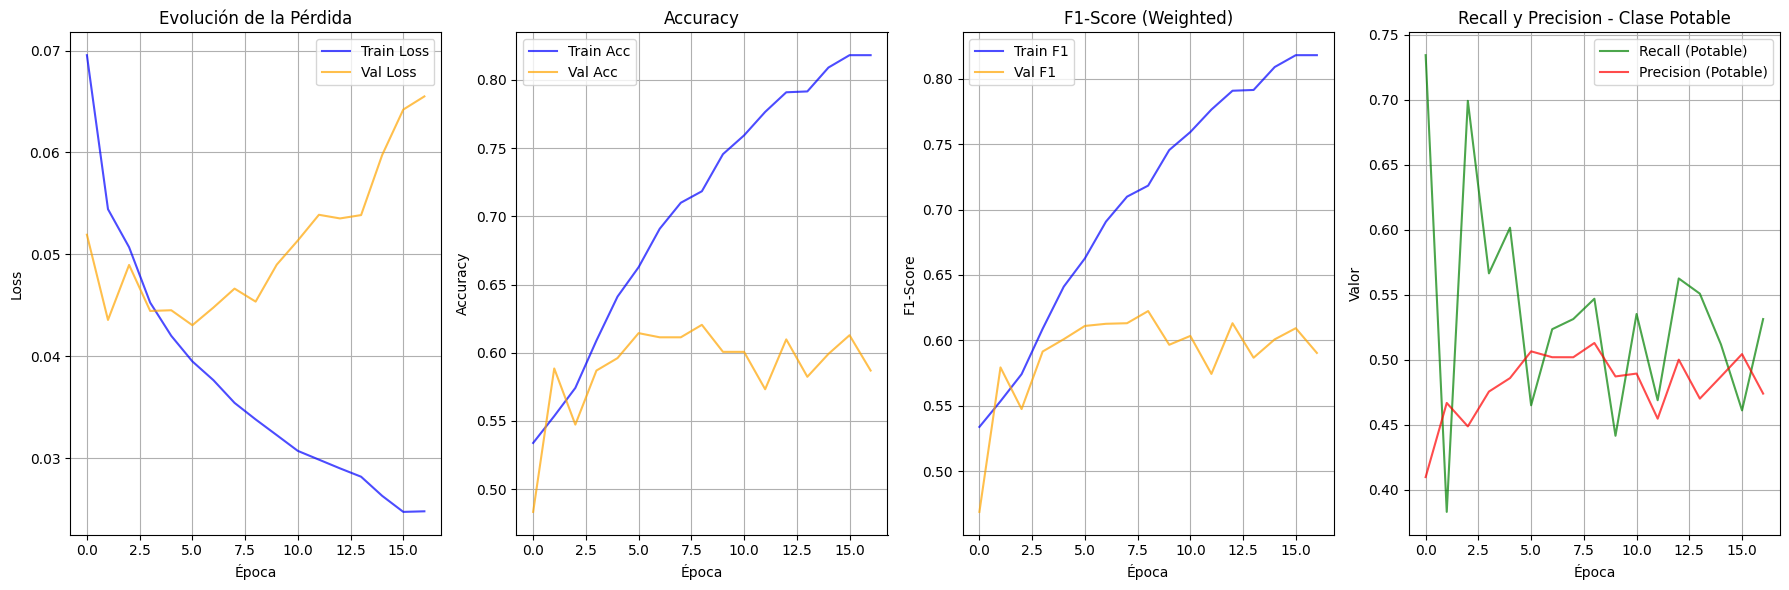

In [12]:
print("\n=== VISUALIZANDO PROGRESO DEL ENTRENAMIENTO ===")

plt.figure(figsize=(18, 6))

# Pérdida
plt.subplot(1, 4, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', alpha=0.7)
plt.plot(history['val_loss'], label='Val Loss', color='orange', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Evolución de la Pérdida')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 4, 2)
plt.plot(history['train_acc'], label='Train Acc', color='blue', alpha=0.7)
plt.plot(history['val_acc'], label='Val Acc', color='orange', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

# F1-Score
plt.subplot(1, 4, 3)
plt.plot(history['train_f1'], label='Train F1', color='blue', alpha=0.7)
plt.plot(history['val_f1'], label='Val F1', color='orange', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.title('F1-Score (Weighted)')
plt.legend()
plt.grid(True)

# Recall y Precision
plt.subplot(1, 4, 4)
plt.plot(history['val_recall'], label='Recall (Potable)', color='green', alpha=0.7)
plt.plot(history['val_precision'], label='Precision (Potable)', color='red', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Valor')
plt.title('Recall y Precision - Clase Potable')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



=== BUSCANDO MEJOR UMBRAL DE CLASIFICACIÓN ===

Top 5 umbrales:
 threshold       f1   recall  precision
      0.50 0.622405 0.546875   0.512821
      0.48 0.620275 0.613281   0.506452
      0.54 0.612840 0.390625   0.529101
      0.52 0.612584 0.453125   0.511013
      0.60 0.601096 0.250000   0.621359

 Mejor umbral: 0.500


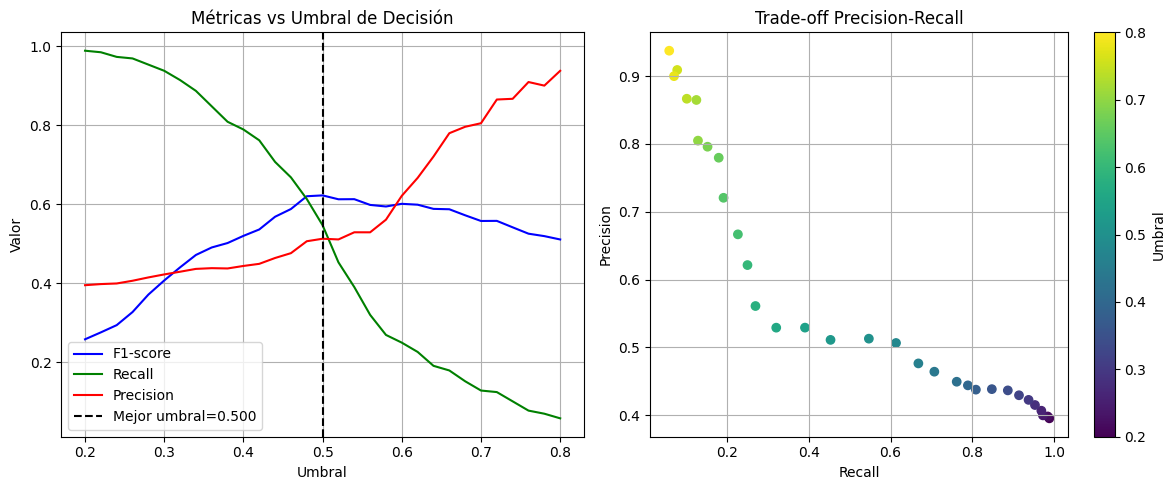

In [13]:
print("\n=== BUSCANDO MEJOR UMBRAL DE CLASIFICACIÓN ===")

best_threshold, threshold_results = find_best_threshold(best_model, dataloaders['val'], device)

# Mostrar resultados
threshold_df = pd.DataFrame(threshold_results)
print("\nTop 5 umbrales:")
print(threshold_df.nlargest(5, 'f1').to_string(index=False))

print(f"\n Mejor umbral: {best_threshold:.3f}")

# Visualizar
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(threshold_df['threshold'], threshold_df['f1'], 'b-', label='F1-score')
plt.plot(threshold_df['threshold'], threshold_df['recall'], 'g-', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['precision'], 'r-', label='Precision')
plt.axvline(x=best_threshold, color='black', linestyle='--', label=f'Mejor umbral={best_threshold:.3f}')
plt.xlabel('Umbral')
plt.ylabel('Valor')
plt.title('Métricas vs Umbral de Decisión')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(threshold_df['recall'], threshold_df['precision'], c=threshold_df['threshold'], cmap='viridis')
plt.colorbar(label='Umbral')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Trade-off Precision-Recall')
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
print("\n=== EVALUACIÓN FINAL DEL MODELO ===")

# Obtener predicciones
best_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs).flatten()
all_labels = np.array(all_labels).flatten()

# Predicciones con mejor umbral
final_preds = (all_probs > best_threshold).astype(int)

print("\n" + "="*60)
print("RESULTADOS FINALES EN VALIDACIÓN")
print("="*60)
print(f"\nUmbral utilizado: {best_threshold:.3f}")
print("\nClassification Report:")
print(classification_report(all_labels, final_preds, target_names=['No Potable', 'Potable']))

# Matriz de confusión
cm = confusion_matrix(all_labels, final_preds)
print("\nMatriz de Confusión:")
print(cm)

# Métricas adicionales
auc = roc_auc_score(all_labels, all_probs)
f1 = f1_score(all_labels, final_preds, average='weighted')
recall_potable = recall_score(all_labels, final_preds, pos_label=1)
precision_potable = precision_score(all_labels, final_preds, pos_label=1)

print(f"\nMétricas resumidas:")
print(f"  AUC-ROC: {auc:.4f}")
print(f"  F1-score (weighted): {f1:.4f}")
print(f"  Recall (Potable): {recall_potable:.4f}")
print(f"  Precision (Potable): {precision_potable:.4f}")


=== EVALUACIÓN FINAL DEL MODELO ===

RESULTADOS FINALES EN VALIDACIÓN

Umbral utilizado: 0.500

Classification Report:
              precision    recall  f1-score   support

  No Potable       0.70      0.67      0.68       400
     Potable       0.51      0.55      0.53       256

    accuracy                           0.62       656
   macro avg       0.60      0.61      0.61       656
weighted avg       0.63      0.62      0.62       656


Matriz de Confusión:
[[267 133]
 [116 140]]

Métricas resumidas:
  AUC-ROC: 0.6483
  F1-score (weighted): 0.6224
  Recall (Potable): 0.5469
  Precision (Potable): 0.5128



=== VISUALIZACIONES DETALLADAS ===


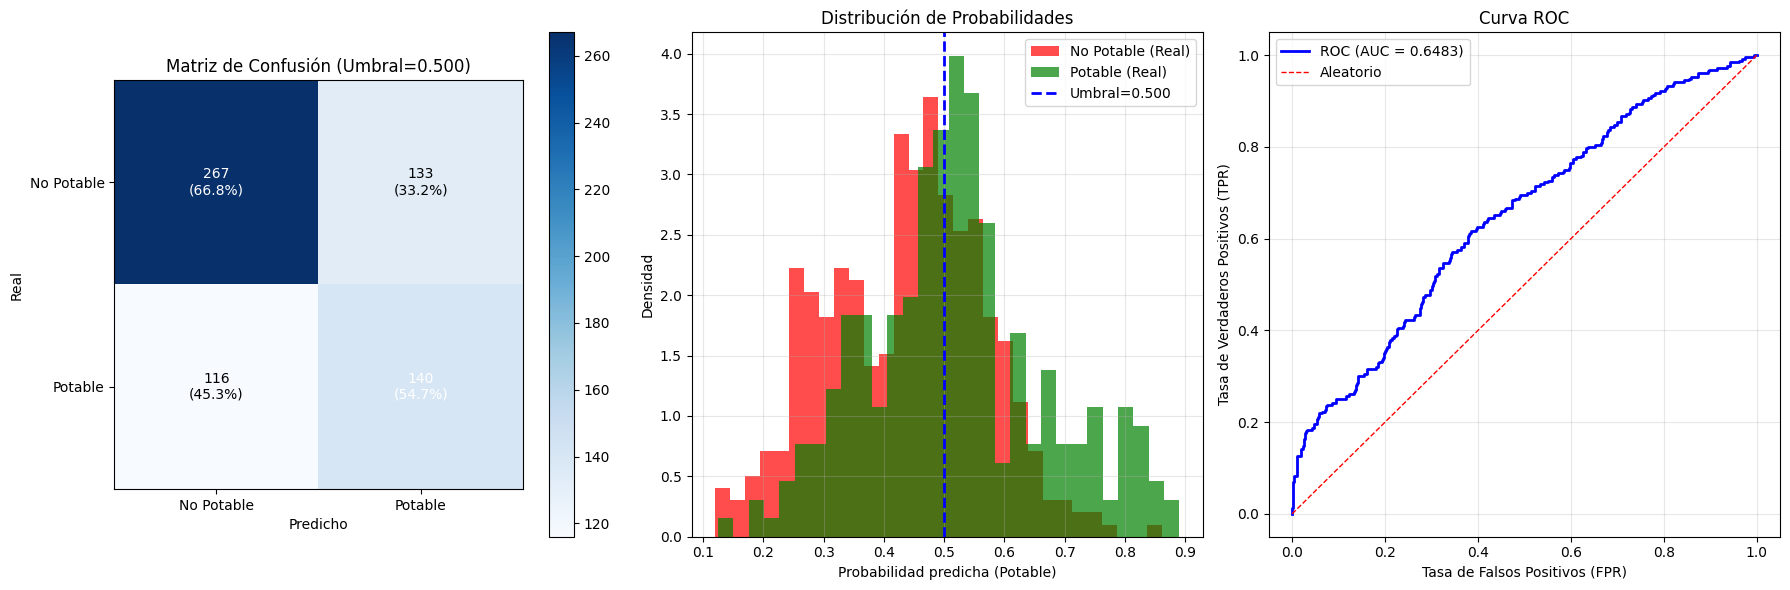

In [15]:
print("\n=== VISUALIZACIONES DETALLADAS ===")

plt.figure(figsize=(18, 6))

# Matriz de confusión
plt.subplot(1, 3, 1)
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f'Matriz de Confusión (Umbral={best_threshold:.3f})')
plt.colorbar()
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks([0, 1], ['No Potable', 'Potable'])
plt.yticks([0, 1], ['No Potable', 'Potable'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]}\n({cm[i, j]/cm.sum(axis=1)[i]*100:.1f}%)", 
                ha='center', va='center', 
                color='white' if cm[i,j] > cm.max()/2 else 'black')

# Distribución de probabilidades
plt.subplot(1, 3, 2)
plt.hist(all_probs[all_labels==0], bins=30, alpha=0.7, label='No Potable (Real)', color='red', density=True)
plt.hist(all_probs[all_labels==1], bins=30, alpha=0.7, label='Potable (Real)', color='green', density=True)
plt.axvline(x=best_threshold, color='blue', linestyle='--', linewidth=2, label=f'Umbral={best_threshold:.3f}')
plt.xlabel('Probabilidad predicha (Potable)')
plt.ylabel('Densidad')
plt.title('Distribución de Probabilidades')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:

print("\n=== COMPARATIVA CON MODELO ANTERIOR ===")

# Datos del modelo anterior (tu resultado)
anterior = {
    'No Potable': {'precision': 0.62, 'recall': 0.99, 'f1': 0.76},
    'Potable': {'precision': 0.83, 'recall': 0.04, 'f1': 0.07}
}

# Datos del modelo actual
actual = classification_report(all_labels, final_preds, output_dict=True)

print("\nComparación Clase Potable:")
print("-" * 50)
print(f"Métrica     | Anterior | Actual  | Mejora")
print("-" * 50)
print(f"Recall      | {anterior['Potable']['recall']:.3f}     | {actual['1']['recall']:.3f}   | +{(actual['1']['recall']-anterior['Potable']['recall'])*100:.1f}%")
print(f"Precisión   | {anterior['Potable']['precision']:.3f}     | {actual['1']['precision']:.3f}   | {(actual['1']['precision']-anterior['Potable']['precision'])*100:.1f}%")
print(f"F1-score    | {anterior['Potable']['f1-score']:.3f}     | {actual['1']['f1-score']:.3f}   | +{(actual['1']['f1-score']-anterior['Potable']['f1-score'])*100:.1f}%")
print("-" * 50)

# Visualizar comparativa
plt.figure(figsize=(10, 6))
metrics = ['Recall', 'Precision', 'F1-score']
x = np.arange(len(metrics))
width = 0.35

anterior_vals = [anterior['Potable']['recall'], anterior['Potable']['precision'], anterior['Potable']['f1-score']]
actual_vals = [actual['1']['recall'], actual['1']['precision'], actual['1']['f1-score']]

plt.bar(x - width/2, anterior_vals, width, label='Modelo Anterior', color='red', alpha=0.7)
plt.bar(x + width/2, actual_vals, width, label='Modelo Actual', color='green', alpha=0.7)
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.title('Comparativa de Modelos - Clase Potable')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

for i, v in enumerate(anterior_vals):
    plt.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom')
for i, v in enumerate(actual_vals):
    plt.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



=== COMPARATIVA CON MODELO ANTERIOR ===

Comparación Clase Potable:
--------------------------------------------------
Métrica     | Anterior | Actual  | Mejora
--------------------------------------------------


KeyError: '1'